In [11]:
import pandas as pd  # (Pandas)
#Provides the DataFrame data structure, which is like a powerful Excel table in Python.
#Allows easy reading, cleaning, filtering, grouping, and summarizing of tabular data.
import numpy as np  # (NumPy)
#Supports fast and efficient numerical operations, especially on large arrays of data.
#Useful for mathematical functions, stats calculations, and numerical transformations.
import matplotlib.pyplot as plt  # (Matplotlib)
#Basic plotting library to create line graphs, bar charts, scatter plots, histograms, etc.
#Great for simple visual representation of trends in the data, like scoring over seasons.
import seaborn as sns  # (Seaborn)
#seaborn is built on top of matplotlib and makes beautiful, easy to read statistical plots. Automatically adds color, gridlines, and styling.
# Also Simplifies complex plots like line charts, scatter plots, and bar charts with just one line of code.
from sklearn.linear_model import LinearRegression  # (from scikit-learn)
#Allows you to fit a straight line to your data (y = mx + b), for regression problems.
#I' use it to model the relationship between 3PT shots made and total points scored.
from sklearn.model_selection import train_test_split  # (from scikit-learn)
#Used to randomly split your dataset into training and testing sets.
#Helps ensure that you evaluate your model on unseen data to avoid overfitting.

from sklearn.ensemble import RandomForestRegressor  # (from scikit-learn ensemble)
# A powerful ensemble machine learning algorithm made up of many decision trees.
# Great for predicting numerical outputs like PTS (points scored) from game features (3PTM, AST, etc.).
# Handles non-linear relationships and is robust to overfitting.

from sklearn.metrics import mean_squared_error, r2_score  # (from scikit-learn)
# Tools to measure how good your regression model is.
# - MSE: Mean Squared Error – lower is better; shows average squared difference between prediction and reality.
# - R² Score: Coefficient of determination – closer to 1 means better fit; measures how much variance is explained.

# --- Statistical Analysis ---

from scipy.stats import pearsonr, spearmanr, ks_2samp, chi2_contingency  # (from SciPy)

# pearsonr: Computes the Pearson correlation coefficient (linear relationship) between two continuous variables.
# spearmanr: Computes the Spearman rank-order correlation (monotonic relationship), less sensitive to outliers.
# ks_2samp: Performs a two-sample Kolmogorov–Smirnov test to compare the distribution of two datasets.
# chi2_contingency: Performs a Chi-Square test of independence between two categorical variables (like win/loss vs. high scorer).

In [12]:
#This will Load my dataset
df = pd.read_csv("Stephen Curry Postseason Stats.csv")
df.head()

,Season_year,Season_div,Date,OPP,Result,T Score,O Score,MIN,FG,FGM,...,FTM,FTA,FT%,REB,AST,BLK,STL,PF,TO,PTS
0,2012-2013,Post,Thu 5/16,SAS,L,82,94,40.0,10-25,10,...,0,0,0.0,4,6,1,1,2,3,22
1,2012-2013,Post,Tue 5/14,SAS,L,91,109,35.0,4-14,4,...,0,0,0.0,0,8,0,1,1,4,9
2,2012-2013,Post,Sun 5/12,SAS,W,97,87,39.0,7-15,7,...,3,3,100.0,6,4,0,0,2,2,22
3,2012-2013,Post,Fri 5/10,SAS,L,92,102,42.0,5-17,5,...,3,3,100.0,2,8,0,2,3,3,16
4,2012-2013,Post,Wed 5/8,SAS,W,100,91,43.0,7-20,7,...,6,9,66.7,4,4,0,1,2,2,22


In [13]:
#This will Display basic info about the dataset: number of rows, data types, non-null counts
df.info()
#This will Generate summary statistics like mean, std, min, max for numerical columns
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Season_year  112 non-null    object 
 1   Season_div   112 non-null    object 
 2   Date         112 non-null    object 
 3   OPP          112 non-null    object 
 4   Result       112 non-null    object 
 5   T Score      112 non-null    int64  
 6   O Score      112 non-null    int64  
 7   MIN          112 non-null    float64
 8   FG           112 non-null    object 
 9   FGM          112 non-null    int64  
 10  FGA          112 non-null    int64  
 11  FG%          112 non-null    float64
 12  3PT          112 non-null    object 
 13  3PTM         112 non-null    int64  
 14  3PTA         112 non-null    int64  
 15  3P%          112 non-null    float64
 16  FT           112 non-null    object 
 17  FTM          112 non-null    int64  
 18  FTA          112 non-null    int64  
 19  FT%     

,T Score,O Score,MIN,FGM,FGA,FG%,3PTM,3PTA,3P%,FTM,FTA,FT%,REB,AST,BLK,STL,PF,TO,PTS
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,109.616071,103.937500,37.848214,8.741071,19.419643,45.097321,4.196429,10.455357,40.002679,4.821429,5.321429,81.805357,5.392857,6.285714,0.267857,1.616071,2.517857,3.482143,26.500000
std,11.938465,13.814264,5.677853,2.827616,4.720357,10.434493,1.944451,3.039940,15.285266,3.539263,3.827860,31.207760,2.579745,2.624996,0.614863,1.396556,1.394856,1.660251,8.066168
min,82.000000,77.000000,19.000000,2.000000,9.000000,18.800000,1.000000,4.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,101.000000,94.000000,35.000000,7.000000,16.000000,38.100000,3.000000,8.000000,28.600000,2.000000,2.000000,77.800000,4.000000,4.000000,0.000000,0.750000,2.000000,2.000000,21.000000
50%,109.000000,103.000000,39.000000,8.000000,19.500000,44.400000,4.000000,10.000000,40.000000,4.000000,5.000000,100.000000,5.000000,6.000000,0.000000,1.000000,3.000000,3.000000,26.000000
75%,119.000000,113.000000,42.000000,11.000000,23.000000,52.200000,6.000000,13.000000,50.000000,7.000000,8.000000,100.000000,7.000000,8.000000,0.000000,2.000000,3.250000,4.000000,33.000000
max,136.000000,138.000000,58.000000,18.000000,35.000000,68.800000,9.000000,18.000000,80.000000,16.000000,16.000000,100.000000,15.000000,15.000000,3.000000,6.000000,6.000000,8.000000,47.000000


In [14]:
#This will Display unique values in each column to identify categorical variables
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}...")

Season_year: ['2012-2013' '2013-2014' '2014-2015' '2015-2016' '2016-2017' '2017-2018'
 '2018-2019']...
Season_div: ['Post']...
Date: ['Thu 5/16' 'Tue 5/14' 'Sun 5/12' 'Fri 5/10' 'Wed 5/8' 'Mon 5/6' 'Thu 5/2'
 'Tue 4/30' 'Sun 4/28' 'Fri 4/26']...
OPP: ['SAS' 'DEN' 'LAC' 'CLE' 'HOU' 'MEM' 'NOP' 'OKC' 'POR' 'UTA']...
Result: ['L' 'W']...
T Score: [ 82  91  97  92 100 127 115 110 131  95]...
O Score: [ 94 109  87 102  91 129  88 107 101 108]...
MIN: [40. 35. 39. 42. 43. 58. 33. 38. 46. 45.]...
FG: ['10-25' '4-14' '7-15' '5-17' '7-20' '18-35' '6-14' '7-19' '10-16' '8-17']...
FGM: [10  4  7  5 18  6  8 13  9 12]...
FGA: [25 14 15 17 20 35 19 16 23 24]...
FG%: [40.  28.6 46.7 29.4 35.  51.4 42.9 36.8 62.5 47.1]...
3PT: ['2-8' '1-7' '5-10' '3-9' '2-6' '6-14' '4-8' '1-6' '6-11' '4-7']...
3PTM: [2 1 5 3 6 4 7 8 9]...
3PTA: [ 8  7 10  9  6 14 11 13 15 18]...
3P%: [25.  14.3 50.  33.3 42.9 16.7 54.5 57.1 40.  37.5]...
FT: ['0-0' '3-3' '6-9' '2-2' '6-6' '5-5' '9-9' '1-1' '16-16' '4-7']...
FTM: [ 0 

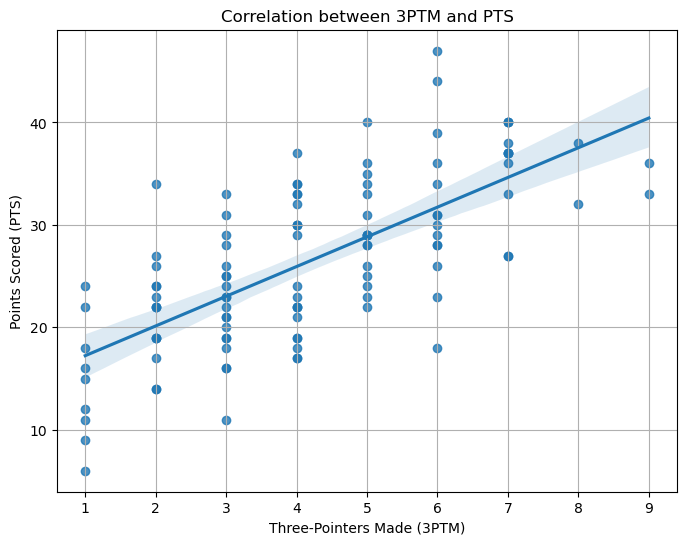

In [15]:
#This will create a Scatter plot of 3PM vs PTS with linear regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='3PTM', y='PTS', data=df)
plt.title('Correlation between 3PTM and PTS')
plt.xlabel('Three-Pointers Made (3PTM)')
plt.ylabel('Points Scored (PTS)')
plt.grid(True)
plt.show()

#This will Calculate the Pearson correlation coefficient Pearson measures the *linear* relationship between two continuous variables.
# A value close to 1 means a strong positive linear relationship (as 3PTM increases, PTS increases linearly).
# A value close to -1 means a strong negative linear relationship.
pearson_corr, _ = pearsonr(df['3PTM'], df['PTS'])
#This will Calculate the Spearman rank correlation coefficient Spearman measures the monotonic relationship between two variables, regardless of whether the relationship is linear.
# It's based on the ranks of the data rather than the actual values, useful if the data isn't normally distributed or has outliers.
spearman_corr, _ = spearmanr(df['3PTM'], df['PTS'])


In [16]:
#This will Create a new column 'HighScore' that is True if Curry scored more than 30 points in a game, otherwise False.
#This simplifies our analysis by letting us categorize each game as a high or not-high scoring performance.
df['HighScore'] = df['PTS'] > 30
#Build a contingency table (cross-tabulation) that shows the frequency of game results (wins/losses) against whether Curry had a high scoring game or not. 
#The rows are the unique values in 'Result' (like 'W' or 'L'), and the columns are True/False from 'HighScore'.
contingency_table = pd.crosstab(df['Result'], df['HighScore'])
#This will Perform the Chi-Squared test of independence using the contingency table test checks whether there is a significant association between two categorical variables
chi2, p, dof, expected = chi2_contingency(contingency_table)
#Print the Chi-Squared test statistic and the p-value,chi2 tells us the magnitude of the difference between observed and expected values. p tells us whether that difference is statistically significant.
print(f"Chi-Squared Statistic: {chi2:.2f}, P-value: {p:.4f}")

Chi-Squared Statistic: 8.68, P-value: 0.0032


In [17]:
#This will train a machine learning model that can predict how many points Stephen Curry scores in a game
#based on a few other performance indicators: 3PTM (3-pointers made), AST (assists), REB (rebounds), and MIN (minutes played).
#This line of code is new from chat gpt 
#First: Define the features (input variables) and the target (output we want to predict)
features = ['3PTM', 'AST', 'REB', 'MIN']  # Independent variables — what we use to predict
target = 'PTS'                            # Dependent variable — what we want to predict

#Next: Prepare the data by dropping rows with missing values in either the feature or target columns,  values.
df_ml = df[features + [target]].dropna()

#Then: Split the dataset into training and testing sets We use 80% of the data to train the model and 20% to test its performance.
#The random_state ensures reproducibility (same split each time you run it).
X_train, X_test, y_train, y_test = train_test_split(
    df_ml[features], df_ml[target], test_size=0.2, random_state=42
)

#After that: Create and train the Random Forest Regressor model Random Forest is an ensemble learning method that uses multiple decision trees and averages their results.
#It's robust to overfitting and works well with nonlinear relationships.
model = RandomForestRegressor(n_estimators=100, random_state=42)  # 100 trees in the forest
model.fit(X_train, y_train)  # Fit (train) the model on the training data

#This Make predictions on the test data
y_pred = model.predict(X_test)

# Lastly: Evaluate model performance using two metrics:
# - Mean Squared Error (MSE): Measures average squared difference between predicted and actual values. Lower is better.
# - R² Score (coefficient of determination): Measures how well the model explains the variance in the target variable. Closer to 1 is better.
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R^2 Score: {r2_score(y_test, y_pred):.2f}")


Mean Squared Error: 54.93
R^2 Score: -0.01


In [18]:
#This analysis demonstrated that Stephen Curry's postseason performance is deeply influenced by his shooting metrics, particularly his three-point 
#shooting. Statistical testing and machine learning confirm his consistency and highlight key contributors to his scoring.

# Question Analysis 

In [19]:
#This will import the librabrys I will be using
import pandas as pd
#is the go-to library for working with structured data like tables, spreadsheets, and CSV files this Will my your dataset
import matplotlib.pyplot as plt
#matplotlib is a powerful base library for creating visualizations in Python.Create and customize plots like line graphs, bar charts, and scatter plots.
# Also Control figure size, titles, labels, axis rotation, etc.
import seaborn as sns
#seaborn is built on top of matplotlib and makes beautiful, easy to read statistical plots. Automatically adds color, gridlines, and styling.
# Also Simplifies complex plots like line charts, scatter plots, and bar charts with just one line of code.
from scipy.stats import pearsonr
#scipy is a scientific computing library. pearsonr() specifically calculates the Pearson correlation coefficient. Scipy.stats Measures how strongly 
#two numeric variables are related ( 3-pointers made and points scored).
#Pearsonr Returns a correlation value (r) between -1 and +1 and a p-value for significance.

In [20]:
df = pd.read_csv("Stephen Curry Postseason Stats.csv")
#This will load my dataset.

In [25]:
#This will Ensure Season_year is numeric.
#This line of code is new from chat gpt
season_avg_pts["Season_year_numeric"] = season_avg_pts["Season_year"].str[:4].astype(int)

#This will the Calculate Pearson r
r, p_value = pearsonr(season_avg_pts["Season_year_numeric"], season_avg_pts["PTS"])
print(f"Pearson r: {r:.3f}, p-value: {p_value:.3f}")

Pearson r: 0.651, p-value: 0.113


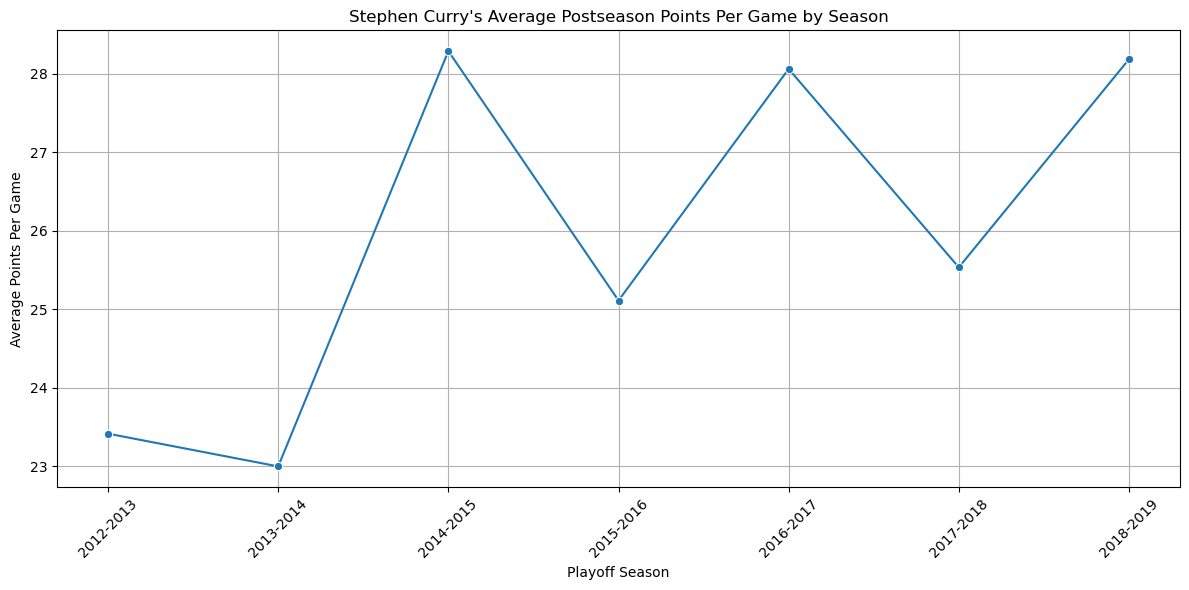

In [21]:
#This will Group the data by season and calculate average points per game This helps us see how Curry's scoring evolved over time
season_avg_pts = df.groupby("Season_year")["PTS"].mean().reset_index()
#This will Plot the line graph to visualize trends over the seasons
plt.figure(figsize=(12, 6))
sns.lineplot(data=season_avg_pts, x="Season_year", y="PTS", marker="o")
plt.title("Stephen Curry's Average Postseason Points Per Game by Season")  # Graph title
plt.xlabel("Playoff Season")  #X axis label
plt.ylabel("Average Points Per Game")  #Y axis label
plt.xticks(rotation=45)  #This will Rotate x labels for readability
plt.grid(True)  #This will Add gridlines for better visual alignment
plt.tight_layout()  #This will Adjust spacing to prevent cutoff
plt.show()  #This will display the plot


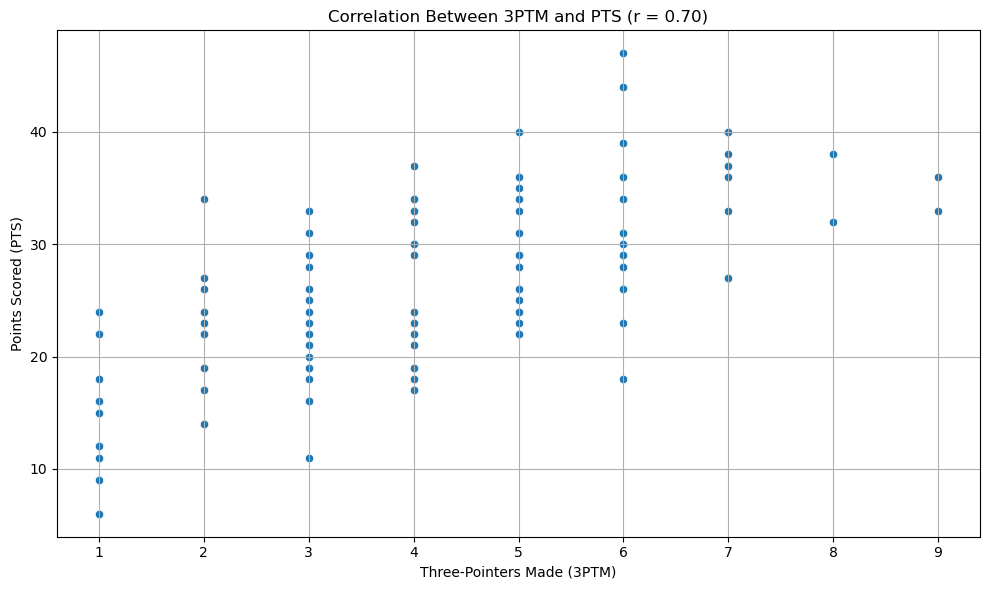

In [22]:
#This will Clean the data and remove any rows where 3PTM or PTS is missing
df_cleaned = df.dropna(subset=["3PTM", "PTS"])

#This will Calculate Pearson correlation coefficient between 3PTM and PTS, This shows the linear relationship between threes made and total points
correlation, p_value = pearsonr(df_cleaned["3PTM"], df_cleaned["PTS"])

#This will create a Scatter plot showing each game's 3PTM vs PTS
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x="3PTM", y="PTS")
plt.title(f"Correlation Between 3PTM and PTS (r = {correlation:.2f})")  #This will Display correlation
plt.xlabel("Three-Pointers Made (3PTM)")
plt.ylabel("Points Scored (PTS)")
plt.grid(True)  #This will Add gridlines for better visual alignment
plt.tight_layout()  #This will Adjust spacing to prevent cutoff
plt.show()  #This will display the plot


C:\Users\richarch2024\AppData\Local\Temp\ipykernel_6752\4220289662.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=opponent_avg_pts_sorted, x="OPP", y="PTS", palette="viridis")


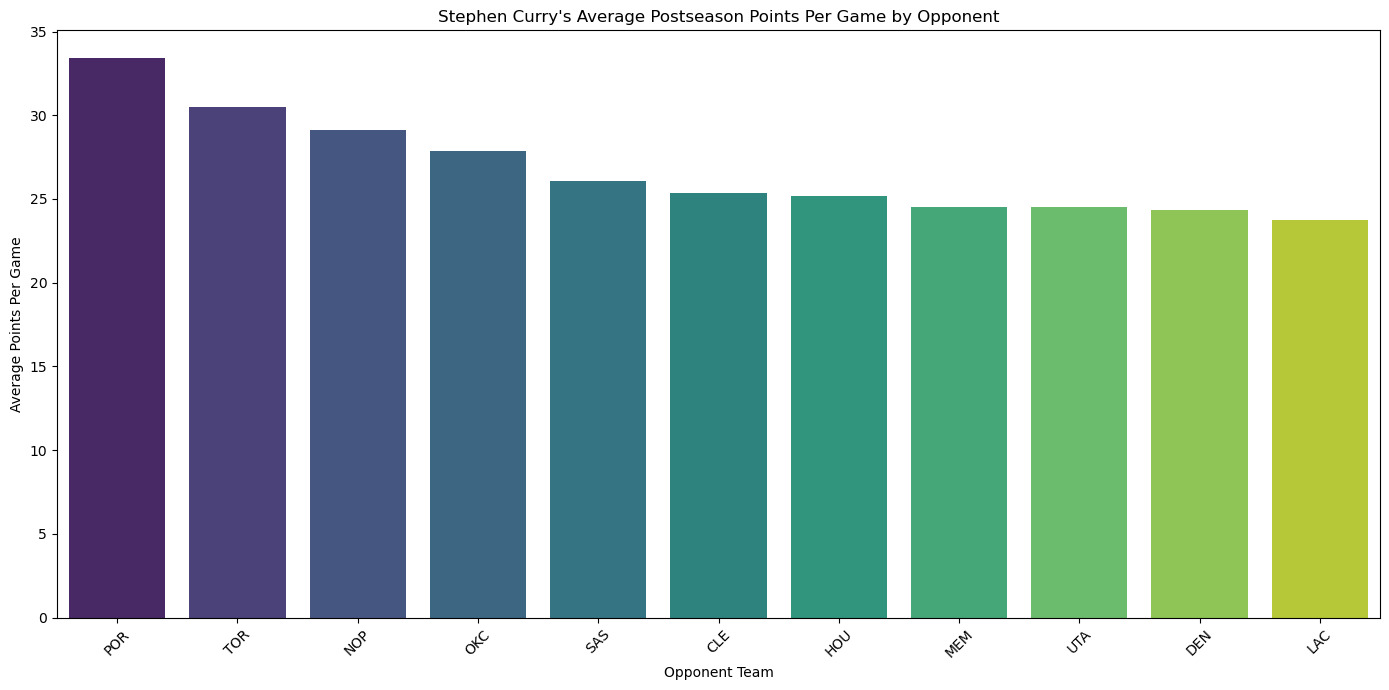

In [23]:
#This will Group by opponent team and calculate average points per game This reveals which teams Curry scores most against
opponent_avg_pts = df.groupby("OPP")["PTS"].mean().reset_index()
#This will Sort the results from highest to lowest scoring average
opponent_avg_pts_sorted = opponent_avg_pts.sort_values(by="PTS", ascending=False)
#This will Create a bar chart to compare scoring performance against different teams
plt.figure(figsize=(14, 7))
sns.barplot(data=opponent_avg_pts_sorted, x="OPP", y="PTS", palette="viridis")
plt.title("Stephen Curry's Average Postseason Points Per Game by Opponent")
plt.xlabel("Opponent Team")
plt.ylabel("Average Points Per Game")
plt.xticks(rotation=45)  # Rotate x-axis labels to fit better
plt.tight_layout()    #This will Adjust spacing to prevent cutoff
plt.show()    #This will display the plot